# When is carbon dioxide an ideal gas?

**Skills: writing a function, root finding, looping, plotting.** Work through
*Getting started with Python and Jupyter* first if you have not already.

The ideal gas law can be rearranged for the molar volume by hand:
$\underline{V} = RT/P$. Most equations of state cannot. The **van der Waals** equation,

$$\left(P + \frac{a}{\underline{V}^{2}}\right)\left(\underline{V} - b\right) = RT,$$

is the simplest one that accounts for molecules having a size and attracting one another.
It is developed in **Chapter 6** — here it is simply handed to you, because what we are
practicing is Python, not thermodynamics. Multiply it out and you have a *cubic* in
$\underline{V}$. There is a formula for the roots of a cubic, and nobody uses it.

Instead you rearrange the equation so that one side is zero,

$$f(\underline{V}) = RT - \left(P + \frac{a}{\underline{V}^{2}}\right)\left(\underline{V} - b\right) = 0,$$

and hand $f$ to a **root finder**: a routine that hunts for the value of $\underline{V}$
that makes $f$ vanish. That single idea does most of the numerical work in this book.

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

## 1. One temperature, one pressure

The constants $a$ and $b$ are properties of the substance. For carbon dioxide,
$a = 0.3658\ \mathrm{Pa\,m^{6}/mol^{2}}$ and $b = 4.286\times10^{-5}\ \mathrm{m^{3}/mol}$.

`brentq` is SciPy's workhorse root finder. It needs the function and **two volumes that
bracket the root** — one where $f$ is positive and one where it is negative. It is
guaranteed to find a root between them.

The lower limit is not arbitrary. In the van der Waals equation $b$ is the volume the
molecules themselves occupy, so no real state has $\underline{V} \le b$; we start just
above it. For the upper limit, 1 m³/mol is far larger than any gas at these conditions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

R = 8.314          # J/(mol K)
a = 0.3658         # Pa m^6/mol^2 , carbon dioxide
b = 4.286e-5       # m^3/mol      , carbon dioxide


def f(V, T, P):
    """Zero when V is the van der Waals molar volume at T, P. SI units throughout."""
    return R * T - (P + a / V**2) * (V - b)


T = 300.0          # K
P = 50.0e5         # Pa  (50 bar)

V_vdw = brentq(f, 1.001 * b, 1.0, args=(T, P))
V_ideal = R * T / P

print(f"van der Waals : {V_vdw:.4e} m^3/mol")
print(f"ideal gas     : {V_ideal:.4e} m^3/mol")
print(f"difference    : {100 * (V_vdw - V_ideal) / V_ideal:+.1f} %")
print(f"Z = PV/RT     : {P * V_vdw / (R * T):.3f}")

van der Waals : 3.6465e-04 m^3/mol
ideal gas     : 4.9884e-04 m^3/mol
difference    : -26.9 %
Z = PV/RT     : 0.731


At 300 K and 50 bar, carbon dioxide occupies **27% less** volume than the ideal gas law
predicts. The compressibility factor $Z = P\underline{V}/RT$ is 0.731 instead of 1 — and
$Z$ measures departure from ideality in a single number,
regardless of the units you chose.

Notice that `f` takes `T` and `P` as arguments and `brentq` passes them through with
`args=(T, P)`. It is tempting to let the function read `T` and `P` from the surrounding
notebook instead, and it even works — until you change one of them in a cell further down
and forget which cells depended on it. Pass what a function needs.

## 2. Wrap it up so you can reuse it

Two small functions, and the rest of the notebook is short. Each does one thing and
returns a number.

In [4]:
def molar_volume_vdw(T, P):
    """van der Waals molar volume, m^3/mol. T in K, P in Pa."""
    return brentq(f, 1.001 * b, 1.0, args=(T, P))


def deviation(T, P):
    """Percentage by which the vdW molar volume differs from the ideal-gas value."""
    V_ideal = R * T / P
    return 100.0 * (molar_volume_vdw(T, P) - V_ideal) / V_ideal


print(f"{deviation(300.0, 50.0e5):+.1f} %  at 300 K, 50 bar")
print(f"{deviation(300.0,  1.0e5):+.2f} %  at 300 K,  1 bar")

-26.9 %  at 300 K, 50 bar
-0.42 %  at 300 K,  1 bar


## 3. One temperature, many pressures

At 1 bar the two answers agree to better than half a percent, and at 50 bar they are 27%
apart. Somewhere in between is the pressure where treating carbon dioxide as ideal stops
being defensible.

`brentq` works on one pressure at a time, so this is a job for a loop — build a list, then
turn it into an array so it can be plotted. (Contrast this with the ideal-gas line, which
takes the whole array at once.)

In [5]:
pressures = np.linspace(1.0e5, 60.0e5, 60)      # 1 to 60 bar, in Pa

deviations = []
for P in pressures:
    deviations.append(deviation(300.0, P))
deviations = np.array(deviations)

print(f"{'P (bar)':>9}{'deviation (%)':>15}")
for P, d in zip(pressures[::10], deviations[::10]):
    print(f"{P / 1e5:9.0f}{d:15.2f}")

  P (bar)  deviation (%)
        1          -0.42
       11          -4.77
       21          -9.49
       31         -14.71
       41         -20.63
       51         -27.68


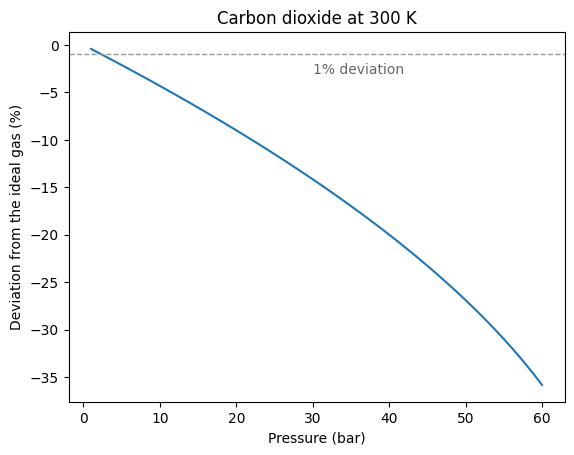

In [6]:
fig, ax = plt.subplots()
ax.plot(pressures / 1e5, deviations)
ax.axhline(-1.0, color="0.6", ls="--", lw=1)
ax.set_xlabel("Pressure (bar)")
ax.set_ylabel("Deviation from the ideal gas (%)")
ax.set_title("Carbon dioxide at 300 K")
ax.text(30, -3.0, "1% deviation", color="0.4")
plt.show()

## 4. Where is the 1% line?

You could read the crossing off the graph. Better: the crossing *is* a root — of the
function "deviation minus one percent" — and you already have a root finder. This is why you
learn `brentq` rather than a recipe for cubics: it solves whatever equation
you give it.

The magnitude `abs(...)` is deliberate. Below the temperature we are working at, the van
der Waals volume is *smaller* than the ideal one and the deviation is negative; above a
certain temperature it turns positive. Bracketing on the size of the deviation works
either way.

In [7]:
P_1pct = brentq(lambda P: abs(deviation(300.0, P)) - 1.0, 1.0e4, 60.0e5)

print(f"At 300 K the two molar volumes differ by 1% at {P_1pct / 1e5:.2f} bar.")

At 300 K the two molar volumes differ by 1% at 2.38 bar.


**2.4 bar.** Carbon dioxide near room temperature stops being an ideal gas at barely
twice atmospheric pressure — which is the answer to the question in the title, and a good
deal lower than most people would guess.

There is an independent check available, and taking it is a habit to form now.
Problem 1.5 expands the van der Waals equation to show that at large molar volumes

$$Z \approx 1 + \frac{B(T)}{\underline{V}}, \qquad B(T) = b - \frac{a}{RT},$$

so a 1% departure needs $|B|/\underline{V} \approx 0.01$, i.e. $P \approx 0.01\,RT/|B|$.
That is algebra, done by hand, with no root finder anywhere near it. If the two agree, it
is very unlikely that both are wrong.

In [8]:
B = b - a / (R * 300.0)                       # second virial coefficient, m^3/mol
P_estimate = 0.01 * R * 300.0 / abs(B)       # Pa

print(f"B(300 K)        = {B:.3e} m^3/mol")
print(f"hand estimate   = {P_estimate / 1e5:.2f} bar")
print(f"root finder     = {P_1pct / 1e5:.2f} bar")

B(300 K)        = -1.038e-04 m^3/mol
hand estimate   = 2.40 bar
root finder     = 2.38 bar


## 5. Why the pressures stopped at 60 bar

Everything above was computed at 300 K, and the van der Waals critical temperature of
carbon dioxide is 304 K. We are just below it, and above roughly 68 bar the equation
stops having one answer: $f(\underline{V})$ crosses zero **three** times, because the
equation is describing a gas, a liquid, and an unstable state in between. Choosing among
them is what Chapter 7 is about.

For now, look at what that does to the root finder. Plot $f$ itself.

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: the whole range the root finder searches.
V = np.linspace(0.8e-4, 5.0e-4, 400)
for P_bar in (50.0, 70.0):
    ax1.plot(V * 1e4, f(V, 300.0, P_bar * 1e5), label=f"{P_bar:.0f} bar")
ax1.axhline(0.0, color="0.6", lw=1)
ax1.set_title("The whole search range")
ax1.legend()

# Right: the same curves, zoomed on the small-volume end.
V_zoom = np.linspace(0.9e-4, 2.0e-4, 400)
for P_bar in (50.0, 70.0):
    ax2.plot(V_zoom * 1e4, f(V_zoom, 300.0, P_bar * 1e5), label=f"{P_bar:.0f} bar")
ax2.axhline(0.0, color="0.6", lw=1)
ax2.set_ylim(-30, 30)
ax2.set_title("Zoomed in: 70 bar crosses zero three times")

for ax in (ax1, ax2):
    ax.set_xlabel("Molar volume  ($10^{-4}$ m$^3$/mol)")
    ax.set_ylabel("$f(\\underline{V})$   (J/mol)")
fig.tight_layout()
plt.show()

ValueError: 
f(\underline{V})
  ^
ParseFatalException: Unknown symbol: \underline, found '\'  (at char 2), (line:1, col:3)

Error in callback <function _draw_all_if_interactive at 0x7fdade1d3560> (for post_execute):


ValueError: 
f(\underline{V})
  ^
ParseFatalException: Unknown symbol: \underline, found '\'  (at char 2), (line:1, col:3)

ValueError: 
f(\underline{V})
  ^
ParseFatalException: Unknown symbol: \underline, found '\'  (at char 2), (line:1, col:3)

<Figure size 1000x400 with 2 Axes>

The 50 bar curve crosses zero once, so there is one answer and `brentq` cannot get it
wrong. The 70 bar curve crosses **three** times, and which root you get then depends
entirely on the bracket you handed in — the routine returns a root between your two
limits, not the one you had in mind. A root finder is not a black box: you have to know
roughly where the answer is.

Staying below 60 bar keeps this notebook in the single-root region. It is a real
limitation, stated rather than hidden.

## What this notebook shows

- **Rearrange to $f(x) = 0$ and hand it to a root finder.** That one move replaces closed-form
  algebra through most of this book, and `brentq` is the same three lines every time.
- **A root finder needs a bracket, and the bracket is physics.** $\underline{V} > b$ because
  molecules occupy space; the three roots at 70 bar are a gas, a liquid and an unstable
  state. The routine will not tell you which one you wanted.
- **Carbon dioxide is not an ideal gas at 300 K above about 2.4 bar** — a much lower
  pressure than intuition suggests, and $Z = 0.731$ at 50 bar.
- **Check a numerical answer against a hand calculation whenever one exists.** The virial
  estimate needs no computer and lands within 1% of the root finder.

## Your turn

1. Repeat §1 at 300 K and 5 bar. Is the deviation what the graph in §3 leads you to expect?
2. The **Boyle temperature** $T_B = a/bR$ is the temperature at which $B(T) = 0$. Work it
   out for carbon dioxide, then find the pressure at which the deviation reaches 1% there.
   You will need to widen the bracket in §4 well beyond 60 bar. Why is the answer so much
   larger, and why is the sign of the deviation now the other way round?
3. Change `a` and `b` to the values for a different gas and redo §3 and §4. Which gas
   stays ideal to the highest pressure, and what about $a$ and $b$ explains it?
4. Add the ideal-gas and van der Waals molar volumes to the same plot, as
   $\underline{V}$ against $P$, instead of plotting the difference between them. Which
   plot makes the departure easier to see, and why?

Part 1

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

R = 8.314          # J/(mol K)
a = 0.3658         # Pa m^6/mol^2 , carbon dioxide
b = 4.286e-5       # m^3/mol      , carbon dioxide


def f(V, T, P):
    """Zero when V is the van der Waals molar volume at T, P. SI units throughout."""
    return R * T - (P + a / V**2) * (V - b)


T = 300.0          # K
P = 5.0e5         # Pa  (5 bar)

V_vdw = brentq(f, 1.001 * b, 1.0, args=(T, P))
V_ideal = R * T / P

print(f"van der Waals : {V_vdw:.4e} m^3/mol")
print(f"ideal gas     : {V_ideal:.4e} m^3/mol")
print(f"difference    : {100 * (V_vdw - V_ideal) / V_ideal:+.1f} %")
print(f"Z = PV/RT     : {P * V_vdw / (R * T):.3f}")

van der Waals : 4.8827e-03 m^3/mol
ideal gas     : 4.9884e-03 m^3/mol
difference    : -2.1 %
Z = PV/RT     : 0.979
